In [15]:
import numpy as np 
import torch
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN
import matplotlib.pyplot as plt 
import torch.nn as nn 
from torchvision.transforms import ToTensor
import seaborn as sns
import torch.nn.functional as F
from pyPLNmodels.utils import log_stirling
import threading
import time

In [16]:
torch.set_printoptions(precision=3)

In [17]:
d = 2
n = 200;  p = 50
q = 5

In [18]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
    
#device = torch.device('cpu') # think I can't use RTX A5000 right now, will check this later. 

torch.cuda.is_available()
#device = torch.device('cpu')

False

In [20]:
device

device(type='cpu')

In [21]:
# 0 est pas mal 
#torch.manual_seed(0)
Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,10))/1 #+ 0.5*torch.eye(p)
#Sigma_sampling = torch.eye(p)

true_C = C_from_Sigma(Sigma_sampling, q).to(device)
true_Sigma_sampling = true_C@(true_C.T)
true_beta =torch.randn((d, p), device = device)/3
covariates = torch.randn((n,d)).to(device)
O =  0*torch.randint(2,(n,p)).to(device)
Y, Z, _  = sample_PLN(true_C,true_beta, O, covariates)

In [23]:
def plot(model):
    '''
    Plot a model, in most casesa neural network
    It will plot the training loss through epoch, and also the test loss. 
    '''
    train_length = len(model.training_loss_list)
    fig, ax = plt.subplots(2,1)
    ax[0].plot(np.arange(train_length), model.training_loss_list, label = 'Training_loss') 
    ax[0].set_yscale('log')
    try:
        test_length = len(model.test_loss_list)
        ax[1].plot(np.arange(test_length), model.test_loss_list, label = 'Test loss')
    except: 
        print('The model has not been tested, wont plot the test loss') 
    ax[0].legend()
    ax[1].legend()
    
    plt.show()


def get_batch(X,y= None, batch_size = 50):
    '''Get the batches required to do a  minibatch gradient ascent.

    Args:
        X: torch.tensor of size (n, n_features).
        y: torch.tensor. Target, if supervised model, of size n. 
            Default is None (unsupervised model)   
        batch_size: int. The batch size. Should be lower than n. Default is 50
       
    Returns: A generator. Will generate n//batch_size + 1 batches of
        size batch_size (except the last one since the rest of the
        division is not always 0)
    '''
    n = X.shape[0]


    indices = np.arange(n)
    # Shuffle the indices to avoid a regular path.
    np.random.shuffle(indices)
    # Set the batch size of the model to the right size
    # get the number of batches and the size of the last one.
    nb_full_batch, last_batch_size = n // batch_size, n % batch_size
    if y == None: 
        for i in range(nb_full_batch):
            yield X[indices[i * batch_size: (i + 1) * batch_size]]
                   
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            yield X[indices[-last_batch_size:]]
                   
        
    else: 
        if y.shape[0]!= n:
            raise AttributeError('X and y does not have the same shape')
        for i in range(nb_full_batch):
            yield (X[indices[i * batch_size: (i + 1) * batch_size]],
                   y[indices[i *batch_size: (i + 1) * batch_size]],
                   )
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            yield (X[indices[-last_batch_size:]],
                   y[indices[-last_batch_size:]],
                   )
            


In [25]:
class PLN_encoder(nn.Module):
    
    def __init__(self, input_dim, q): 
        super().__init__()        
        self.input_dim = input_dim 
        self.q = q 

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 30), # (N, 784) -> (N, 128)
            nn.ReLU(),
            nn.Linear(30, 20),
            nn.ReLU(),
            nn.Linear(20, 12),
            nn.ReLU(),
            #nn.Linear(12, q) # -> N, 3
        )
        
        self.z_mean = torch.nn.Linear(12, self.q)
        self.z_log_var = torch.nn.Linear(12, self.q)
        
        self.decoder = nn.Sequential(
            nn.Linear(q, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            #nn.Sigmoid()
        )
        self.criterion = nn.MSELoss()
        self.training_loss_list = []
        self.test_loss_list = []
        self.min_test_loss = 1e30
        
        
        
    def encoding_fn(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        return encoded
        
    def reparameterize(self, z_mu, z_log_var):
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device) 
        z = z_mu# + eps * torch.exp(z_log_var/2.) 
        return z
        
    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        #decoded = self.decoder(encoded)
        return z_mean, z_log_var#, decoded
    
    
    def _train(self,Y,O,covariates, num_epochs, batch_size, 
               optimizer = torch.optim.Adam, model_optimizer = torch.optim.Rprop, 
               lr = 0.001, lr_model = 0.01, verbose = False):
        self.Y = Y
        self.O = O
        self.covariates = covariates
        self.q = q 
        self.d = d
        self.n = n 
        self.p = p
        self.C = torch.randn((self.p, self.q)).to(device)
        self.beta = torch.randn((self.d, self.p)).to(device)
        self.M = torch.randn((self.n, self.q)).to(device)
        self.S = torch.randn((self.n, self.q)).to(device)
        self.model_optimizer = model_optimizer([self.beta, self.C, self.M, self.S], lr = lr_model )
        self.optimizer = optimizer(self.parameters(),lr=lr)
        self.train()
        self.to(device)
        self.mse_loss = nn.MSELoss(reduction = 'sum')
        self.beta.requires_grad_(True)
        self.M.requires_grad_(True)
        self.S.requires_grad_(True)
        self.C.requires_grad_(True)
        

        
        #if len(Y.shape) == 3:
        #    X_train = X_train.unsqueeze(1)
        self.train()

        for i,epoch in enumerate(range(num_epochs)):
            training_loss = 0 
            cmpt = 0 
            for Y_b, O_b, covariates_b, indices in self.get_YOcovbatch(batch_size = batch_size):
                self.Y_b = Y_b 
                self.O_b = O_b
                self.covariates_b = covariates_b
                z_mean, z_log_var = self.forward(Y_b)
                #print('decode, ', decoded.shape)
                KL = self.my_loss(z_mean, z_log_var )
                #loss = KL + self.mse_loss(decoded, img)
                '''
                kl_div = -0.5 * torch.sum(1 + z_log_var 
                          - z_mean**2 
                          - torch.exp(z_log_var), 
                          axis=1) # sum over latent dimension
                batchsize = kl_div.size(0)
                kl_div = kl_div.mean() # average over batch dimension

                pixelwise = self.criterion(decoded, img)
                pixelwise = pixelwise.view(batchsize, -1).sum(axis=1) # sum over pixels
                pixelwise = pixelwise.mean() # average over batch dimension
                crit = nn.MSELoss()(decoded, img)
                loss = crit #+ kl_div 
                
                loss = 1*pixelwise + kl_div
                #print('pixelwise crit ', pixelwise)
                '''
                simple_var = False
                if simple_var == False : 
                    loss = -self.elbo_loss(z_mean, z_log_var)
                else: 
                    loss = -ELBO_PCA(self.Y,self.O,self.covariates, self.M, self.S, self.C, self.beta)
                    
                #loss = self.criterion(decoded, img)
                self.optimizer.zero_grad()
                self.model_optimizer.zero_grad()
                loss.backward()
                if simple_var == False: 
                    self.optimizer.step()
                self.model_optimizer.step()
                training_loss+= loss.item()
                cmpt += 1
            self.training_loss_list.append(training_loss/(self.n))
            if verbose : 
                print(f'Epoch:{epoch+1}, Training loss:{training_loss/(self.n):.4f}')
            ## Early stopping 
        print('Training finished')
        
    def my_loss(self, mu, logvar): 
        return - 1/2* torch.sum(1 + logvar - mu**2 - torch.exp(logvar))
    
    def elbo_loss(self, mu, log_var): 
        return ELBO_PCA(self.Y_b,self.O_b,self.covariates_b, mu, torch.exp(log_var), self.C, self.beta)
    
            
    def get_YOcovbatch(self,batch_size):
        '''Get the batches required to do a  minibatch gradient ascent.

        Args:
            batch_size: int. The batch size. Should be lower than n.

        Returns: A generator. Will generate n//batch_size + 1 batches of
            size batch_size (except the last one since the rest of the
            division is not always 0)
        '''
        indices = np.arange(self.n)
        # Shuffle the indices to avoid a regular path.
        np.random.shuffle(indices)
        # Set the batch size of the model to the right size
        self.batch_size = batch_size
        # get the number of batches and the size of the last one.
        nb_full_batch, last_batch_size = self.n // batch_size, self.n % batch_size
        for i in range(nb_full_batch):
            yield (self.Y[indices[i * batch_size: (i + 1) * batch_size]],
                   self.O[indices[i * batch_size: (i + 1) * batch_size]],
                   self.covariates[indices[i *
                                           batch_size: (i + 1) * batch_size]],
                   indices[i * batch_size: (i + 1) * batch_size]
                   )
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            self.batch_size = last_batch_size
            yield (self.Y[indices[-last_batch_size:]],
                   self.O[indices[-last_batch_size:]],
                   self.covariates[indices[-last_batch_size:]],
                   indices[-last_batch_size:]
                   )

In [35]:
class PLN_VAE(nn.Module):
    
    def __init__(self, input_dim, q): 
        super().__init__()        
        self.input_dim = input_dim 
        self.q = q 

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 40), # (N, 784) -> (N, 128)
            nn.ReLU(),
            nn.Linear(40, 30),
            nn.ReLU(),
            nn.Linear(30, 12),
            nn.ReLU(),
            #nn.Linear(12, q) # -> N, 3
        )
        
        self.z_mean = torch.nn.Linear(12, self.q)
        self.z_log_var = torch.nn.Linear(12, self.q)
        
        self.decoder = nn.Sequential(
            nn.Linear(q, 12),
            nn.ReLU(),
            nn.Linear(12, 30),
            nn.ReLU(),
            nn.Linear(30, 40),
            nn.ReLU(),
            nn.Linear(40, input_dim),
            #nn.Sigmoid()
        )
        self.criterion = nn.MSELoss()
        self.training_loss_list = []
        self.test_loss_list = []
        self.min_test_loss = 1e30
        
        
    def recon_loss(self, phiz): 
        return -torch.sum(-torch.exp(self.O_b + phiz) + torch.multiply(phiz + self.O_b,self.Y_b
                                                                      ) - log_stirling(self.Y_b))
    
    def KL_loss(self, mu, log_var):
        return -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var))
        
        
    def encoding_fn(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var) # just add a gaussian noise 
        return encoded
        
    def reparameterize(self, mu, log_var):
        eps = torch.randn(mu.size(0), mu.size(1)).to(device) 
        z = mu + eps * torch.exp(log_var/2.) 
        return z
        
    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var) ## add a gaussian noise to the mean and var 
        decoded = self.decoder(encoded)
        return z_mean, z_log_var, decoded
    
    
    def _train(self,Y,O,covariates, num_epochs, batch_size, 
               optimizer = torch.optim.Adam, model_optimizer = torch.optim.Rprop, 
               lr = 0.001, lr_model = 0.01, verbose = False):
        self.Y = Y
        self.O = O
        self.covariates = covariates
        self.q = q 
        self.d = d
        self.n = n 
        self.p = p
        self.C = torch.randn((self.p, self.q)).to(device)
        self.beta = torch.randn((self.d, self.p)).to(device)
        #self.M = torch.randn((self.n, self.q)).to(device)
        #self.S = torch.randn((self.n, self.q)).to(device)
        #self.model_optimizer = model_optimizer([self.beta, self.C, self.M, self.S], lr = lr_model )
        self.optimizer = optimizer(self.parameters(),lr=lr)
        self.train()
        self.to(device)
        self.mse_loss = nn.MSELoss(reduction = 'sum')
        self.beta.requires_grad_(True)
        #self.M.requires_grad_(True)
        #self.S.requires_grad_(True)
        #self.C.requires_grad_(True)
        

        
        #if len(Y.shape) == 3:
        #    X_train = X_train.unsqueeze(1)
        self.train()

        for i,epoch in enumerate(range(num_epochs)):
            training_loss = 0 
            cmpt = 0 
            for Y_b, O_b, covariates_b, indices in self.get_YOcovbatch(batch_size = batch_size):
                self.Y_b = Y_b 
                self.O_b = O_b
                self.covariates_b = covariates_b
                z_mean, z_log_var, decoded = self.forward(Y_b)
                KL = self.KL_loss(z_mean, z_log_var)
                recon_loss = self.recon_loss(decoded) 
                loss = KL + recon_loss
                self.optimizer.zero_grad()
                #self.model_optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                #self.model_optimizer.step()
                training_loss+= loss.item()
                cmpt += 1
            self.training_loss_list.append(training_loss/(self.n))
            if verbose : 
                print(f'Epoch:{epoch+1}, Training loss:{training_loss/(self.n):.4f}')
            ## Early stopping 
        print('Training finished')
        
    
    def elbo_loss(self, mu, log_var): 
        return ELBO_PCA(self.Y_b,self.O_b,self.covariates_b, mu, torch.exp(log_var), self.C, self.beta)
    
            
    def get_YOcovbatch(self,batch_size):
        '''Get the batches required to do a  minibatch gradient ascent.

        Args:
            batch_size: int. The batch size. Should be lower than n.
            
        Returns: A generator. Will generate n//batch_size + 1 batches of
            size batch_size (except the last one since the rest of the
            division is not always 0)
        '''
        indices = np.arange(self.n)
        # Shuffle the indices to avoid a regular path.
        np.random.shuffle(indices)
        # Set the batch size of the model to the right size
        self.batch_size = batch_size
        # get the number of batches and the size of the last one.
        nb_full_batch, last_batch_size = self.n // batch_size, self.n % batch_size
        for i in range(nb_full_batch):
            yield (self.Y[indices[i * batch_size: (i + 1) * batch_size]],
                   self.O[indices[i * batch_size: (i + 1) * batch_size]],
                   self.covariates[indices[i *
                                           batch_size: (i + 1) * batch_size]],
                   indices[i * batch_size: (i + 1) * batch_size]
                   )
        # Last batch
        # Set the batch size of the model to the right size
        if last_batch_size != 0:
            self.batch_size = last_batch_size
            yield (self.Y[indices[-last_batch_size:]],
                   self.O[indices[-last_batch_size:]],
                   self.covariates[indices[-last_batch_size:]],
                   indices[-last_batch_size:]
                   )

In [36]:
vae = PLN_VAE(50,6)
vae._train(Y,O,covariates, 100, 25, verbose = True)

Epoch:1, Training loss:144.6139
Epoch:2, Training loss:142.9166
Epoch:3, Training loss:141.1498
Epoch:4, Training loss:138.7710
Epoch:5, Training loss:135.0780
Epoch:6, Training loss:130.2770
Epoch:7, Training loss:151.1389
Epoch:8, Training loss:124.6566
Epoch:9, Training loss:121.2452
Epoch:10, Training loss:119.8056
Epoch:11, Training loss:126.8680
Epoch:12, Training loss:117.0333
Epoch:13, Training loss:115.5398
Epoch:14, Training loss:115.2703
Epoch:15, Training loss:114.5831
Epoch:16, Training loss:112.0573
Epoch:17, Training loss:111.5641
Epoch:18, Training loss:111.4109
Epoch:19, Training loss:111.2093
Epoch:20, Training loss:109.0571
Epoch:21, Training loss:108.4868
Epoch:22, Training loss:108.9723
Epoch:23, Training loss:108.6885
Epoch:24, Training loss:109.0454
Epoch:25, Training loss:108.1422
Epoch:26, Training loss:108.3334
Epoch:27, Training loss:108.5686
Epoch:28, Training loss:108.5371
Epoch:29, Training loss:107.6507
Epoch:30, Training loss:107.0260
Epoch:31, Training 

In [27]:
def ELBO_PCA(Y, O, covariates, M, S, C, beta):
    '''compute the ELBO with a PCA parametrization'''
    n = Y.shape[0]
    q = C.shape[1]
    # Store some variables that will need to be computed twice
    A = O + torch.mm(covariates, beta) + torch.mm(M, C.T)
    SrondS = torch.multiply(S, S)
    # Next, we add the four terms of the ELBO_PCA
    YA = torch.sum(torch.multiply(Y, A))
    moinsexpAplusSrondSCCT = torch.sum(-torch.exp(A + 1 / 2 *
                       torch.mm(SrondS, torch.multiply(C, C).T)))
    moinslogSrondS = 1 / 2 * torch.sum(torch.log(SrondS))
    MMplusSrondS = torch.sum(-1 / 2 * (torch.multiply(M, M) + torch.multiply(S, S)))
    log_stirlingY = torch.sum(log_stirling(Y))

    return YA + moinsexpAplusSrondSCCT + moinslogSrondS + MMplusSrondS - log_stirlingY + n * q / 2

lr :  0.001
optim : <class 'torch.optim.adam.Adam'>
Training finished
lr :  0.1
optim : <class 'torch.optim.adam.Adam'>
Training finished


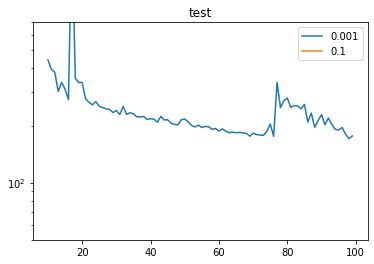

CPU times: user 7.12 s, sys: 224 ms, total: 7.34 s
Wall time: 7.08 s


In [90]:
optim = torch.optim.Adam

lr_list = np.logspace(-3, -1,2)
def plot_lr(optimizer, lr_list, nb_iter, name = 'test'):
    list_training_loss = list()
    for lr in lr_list: 
        print('lr : ', lr)
        lvae = PLN_VAE(p,q)
        lvae._train(Y,O,covariates, nb_iter, batch_size = 15 ,optimizer = optimizer, lr = lr, lr_model = 0.01)
        list_training_loss.append(lvae.training_loss_list)
        
    length = len(list_training_loss[0])

    for i, lr in enumerate(lr_list)  : 
        plt.plot(np.arange(length)[10:] , list_training_loss[i][10:], label = str(lr))

    plt.legend()
    plt.ylim([50,700])
    plt.yscale('log')
    plt.title(name)
    plt.savefig(name)

    plt.show()
    return list_training_loss
        
%time list_training_loss = plot_lr(optim, lr_list, 100)
    

In [68]:
list_training_loss

[[571.8343342431324,
  547.2402301355345,
  528.0601516782344,
  475.7259296310573,
  371.63071255199725,
  507.2335066915417,
  371.57807136109005,
  395.8221391141013,
  9.528634280366268e+17,
  487.22716673111967,
  496.97121663011035,
  461.11333415536484,
  410.46100897521626,
  399.7431274617999,
  392.1950020087025,
  347.24778774674036,
  372.6194569767884,
  313.39662408650094,
  290.60659857649813,
  347.21105653361025,
  287.9342885606872,
  265.6752368828375,
  276.4043838593796,
  252.71326930242566,
  250.17636168314866,
  232.93072659325165,
  225.9174846796906,
  228.92619981357214,
  225.39488975693334,
  213.15418538944442,
  207.11627293166265,
  204.90274639776734,
  200.6796994832899,
  195.0143331839973,
  193.8006522742578,
  222.34584158437417,
  221.3434755536956,
  225.05667334170644,
  199.6211481678058,
  197.93557360577714,
  191.8599518532883,
  188.4770161155995,
  188.34174276615187,
  183.96950107011665,
  187.91211913739954,
  184.6474211160889,
  181.

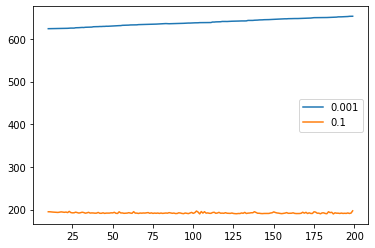

In [53]:
length = len(list_training_loss[0])

for i, lr in enumerate(lr_list)  : 
    plt.plot(np.arange(length)[10:] , list_training_loss[i][10:], label = str(lr))
    
plt.legend()
#plt.savefig(name)
plt.show()

Alg : Adadelta
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


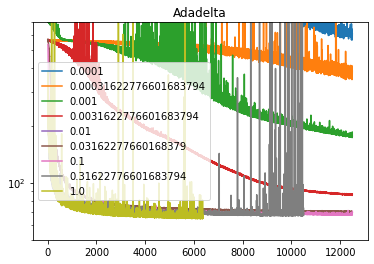

Alg : Adagrad
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


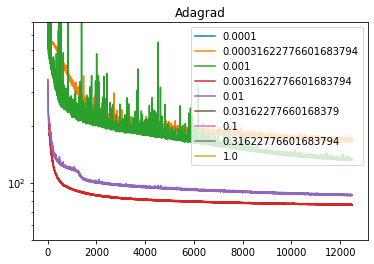

Alg : Adam
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


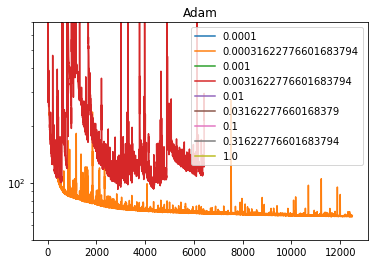

Alg : Adamax
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


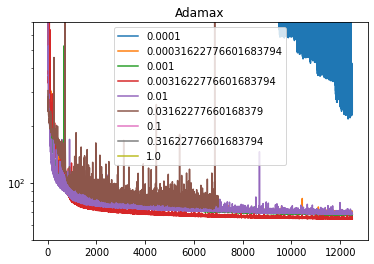

Alg : adamW
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


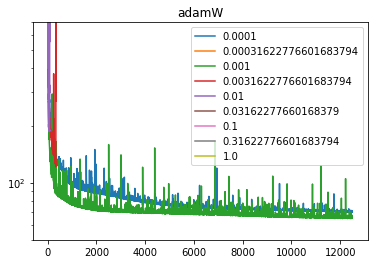

Alg : ASGD
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


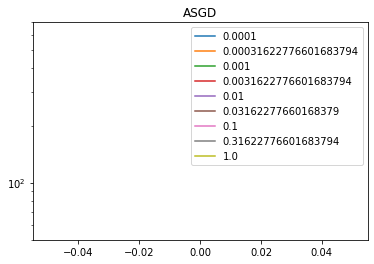

Alg : NAdam
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


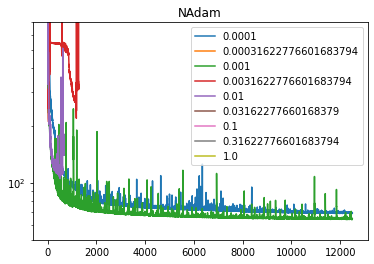

Alg : RAdam
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


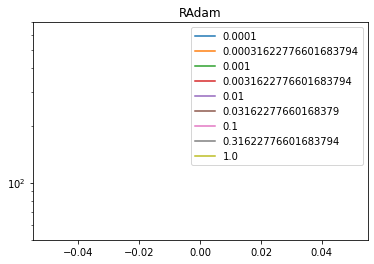

Alg : RMSprop
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


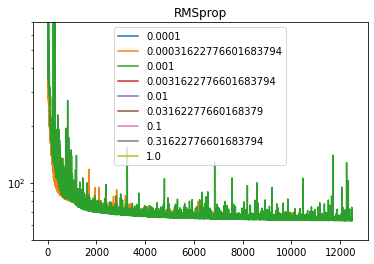

Alg : Rprop
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


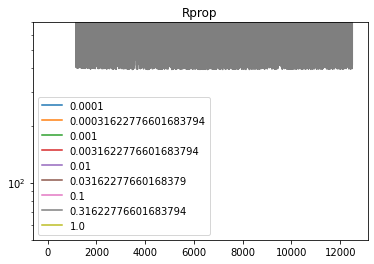

Alg : SGD
lr :  0.0001
Training finished
lr :  0.00031622776601683794
Training finished
lr :  0.001
Training finished
lr :  0.0031622776601683794
Training finished
lr :  0.01
Training finished
lr :  0.03162277660168379
Training finished
lr :  0.1
Training finished
lr :  0.31622776601683794
Training finished
lr :  1.0
Training finished


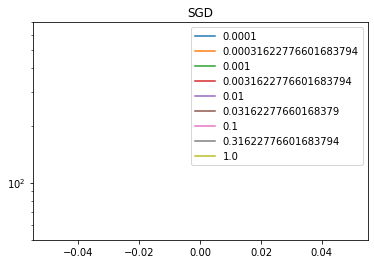

CPU times: user 11h 47min 54s, sys: 4.85 s, total: 11h 47min 59s
Wall time: 11h 47min 58s


In [102]:
def try_optim(dict_optim, lr_list): 
    list_res = list()
    for name, optim in dict_optim.items(): 
        print('Alg :', name)
        res = plot_lr(optim, lr_list,12500, name = name)
        list_res.append(res)
    return list_res
lr_list = lr_list = np.logspace(-4, 0,9)
%time list_res = try_optim(dict_optim, lr_list)

In [103]:
len(list_res[1])

9

In [104]:
len(list_res[0][0])

12500

In [ ]:
def plot_threading_lr(optim, lr_list, nb_iter):     
    list_training_loss = list()
    for lr in lr_list: 
        lvae = PLN_encoder(p,q)
        t = threading.Thread(target =lvae._train,
              args = [Y,O,covariates, nb_iter, 15 , optim, torch.optim.Rprop, lr, 0.01, False])
        list_training_loss.append(lvae.training_loss_list)
        
        t.start()
        ts.append(t)
        models.append(model)
    for t in ts : 
        t.join()
        
        
        
    for lr in lr_list: 
        print('lr : ', lr )
        lvae = PLN_enocder(p,q)
        lvae._train(Y,O,covariates, nb_iter, batch_size = 15 ,optimizer = optim, lr = lr, lr_model = 0.01)
        list_training_loss.append(lvae.training_loss_list)
        
    length = len(list_training_loss[0])

    for i, lr in enumerate(lr_list)  : 
        plt.plot(np.arange(length)[10:] , list_training_loss[i][10:], label = str(lr))

    plt.legend()
    plt.ylim([75,110])
    plt.yscale('log')
    plt.title(name)
    plt.savefig(name)

    plt.show()

In [21]:
dict_optim['Adadelta']

torch.optim.adadelta.Adadelta

In [99]:
dict_optim = {'Adadelta': torch.optim.Adadelta, 'Adagrad': torch.optim.Adagrad, 
             'Adam': torch.optim.Adam,'Adamax': torch.optim.Adamax,'adamW': torch.optim.AdamW,
              'ASGD': torch.optim.ASGD,'NAdam': torch.optim.NAdam,'RAdam': torch.optim.RAdam,
              'RMSprop': torch.optim.RMSprop,'Rprop': torch.optim.Rprop,'SGD': torch.optim.SGD}

<AxesSubplot:>

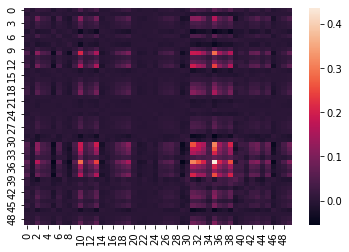

In [36]:
sns.heatmap((lvae.C@(lvae.C.T)).detach())

<AxesSubplot:>

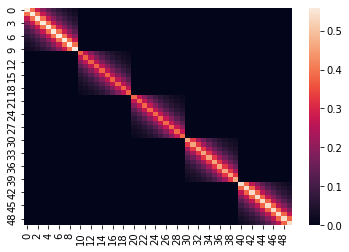

In [116]:
sns.heatmap(Sigma_sampling)

In [223]:
true_beta

tensor([[ 0.064, -0.397, -0.873,  0.158, -0.723,  0.201,  0.560, -0.023, -0.044,
          0.277,  0.036,  0.946, -0.492,  0.522, -0.925, -1.489,  0.554,  0.301,
         -0.830,  1.673, -0.473, -0.289,  1.078,  0.134,  0.236, -0.989,  0.088,
          0.017,  1.008, -0.490, -0.681,  0.825,  0.046, -0.142,  0.093, -0.269,
          0.574,  0.278, -0.111, -0.266,  0.594,  0.398,  1.303, -0.834,  0.335,
         -0.355, -0.147,  0.139,  1.621, -0.060],
        [ 0.370,  0.268, -0.047, -0.593,  0.188, -0.157, -0.636,  1.797, -0.120,
         -0.178,  0.101, -0.822,  0.723, -0.292,  0.979, -0.017,  0.496, -0.649,
         -0.886,  0.266, -0.708,  0.751, -0.134,  1.159,  0.045, -0.231, -1.042,
         -0.820, -0.664,  0.529,  0.893, -0.314,  1.297,  0.318, -0.651,  0.933,
          0.573,  0.081, -0.884, -0.513, -0.101, -0.763, -0.407,  0.341, -0.641,
          0.014, -0.054, -0.048,  1.041, -0.167]])

In [262]:
fastpca = models.fastPLNPCA(q)

In [270]:
fastpca.fit(pd.DataFrame(Y),pd.DataFrame(O),pd.DataFrame(covariates), verbose = True, N_iter_max = 500)

Iteration number:  0
-------UPDATE-------
Delta :  1
Tolerance 0.001 reached in 15 iterations


In [117]:
len(list_res)

11

In [80]:
optim_res[0][1][2] 

[nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan

Adadelta
current min : 565.4245304752727
current min : 349.49838228101214
current min : 172.77886956150138
current min : 85.67211306592047
current min : 2.1309158411585713e+33
current min : 69.63634561408365
current min : 67.40118787239146
current min : 66.542454863904
current min : 64.4819560034505
True min  64.4819560034505 argmin :  1.0
Adagrad
current min : 2.14358613441113e+120
current min : 163.78680505954628
current min : 130.327276453266
current min : 75.93236691095014
current min : 85.36343820559186
current min : nan
current min : nan
current min : nan
current min : nan
True min  75.93236691095014 argmin :  0.0031622776601683794
Adam
current min : nan
current min : 66.11732084266924
current min : 310.3013543663732
current min : 92.24506656384196
current min : 410.87156040468585
current min : nan
current min : nan
current min : nan
current min : nan
True min  66.11732084266924 argmin :  0.00031622776601683794
Adamax
current min : 216.72229209406999
current min : 69.552394679406

/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered


current min : 121.22101284324934
current min : 186.27593844614069
current min : nan
current min : nan
current min : nan
current min : nan
True min  64.7014438493407 argmin :  0.001
ASGD
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
True min  inf argmin :  0.0001
NAdam
current min : 68.70639348973602
current min : nan
current min : 63.870848254880684
current min : 203.98885549955855
current min : 105.1528676638027
current min : nan
current min : nan
current min : nan
current min : nan
True min  63.870848254880684 argmin :  0.001
RAdam
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
True min  inf argmin :  0.0001
RMSprop
current min : nan
current min : 64.51504604286743


/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered


current min : 62.872045283708786
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
True min  62.872045283708786 argmin :  0.001
Rprop
current min : 1211091.8174582284
current min : 522.1840506458294
current min : 525.3079733405124
current min : 14919.998988066254
current min : 259126.98975037868
current min : 15474.760549335157
current min : 1649.084606807214
current min : 394.6798095330406
current min : nan
True min  394.6798095330406 argmin :  0.31622776601683794
SGD
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
current min : nan
True min  inf argmin :  0.0001


/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered
  current_min = np.nanmin(to_plot)
/tmp/ipykernel_68333/2269914403.py:13: RuntimeWarning: All-NaN axis encountered


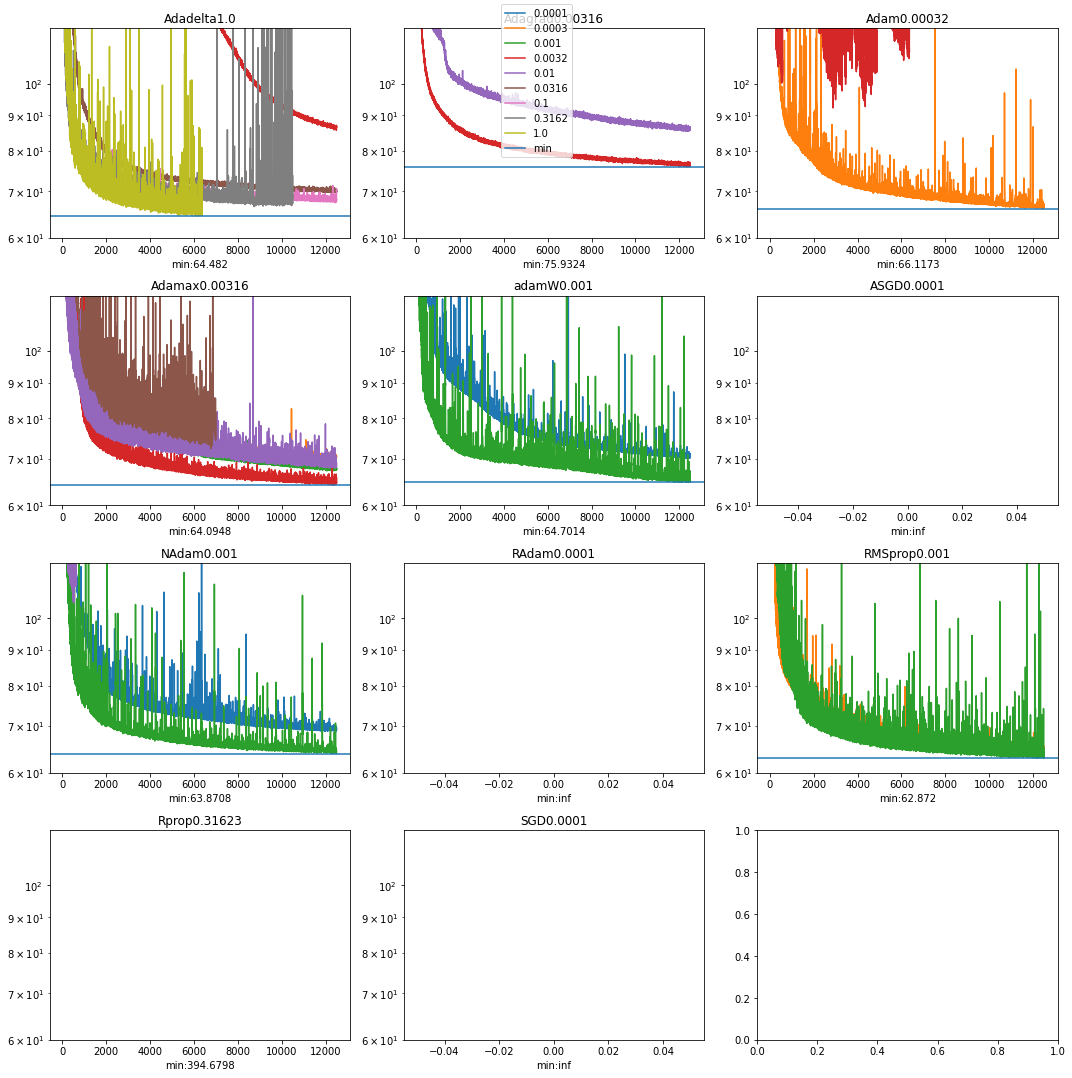

In [128]:
optim_res = list(zip(dict_optim.keys(), list_res))

fig, axes = plt.subplots(4,3, figsize = (15,15))

for i in range(11): 
    x = i//3
    y = i%3
    min_ = np.inf 
    print(optim_res[i][0])
    argmin = 0
    for j in range(9):
        to_plot = optim_res[i][1][j]
        current_min = np.nanmin(to_plot)
        print('current min :', current_min)
        if current_min < min_: 
            min_ = current_min
            argmin = j
        axes[x,y].plot(np.arange(len(to_plot))[50:], to_plot[50:], 
                       label =str(np.round(lr_list[j], 4) ))
    axes[x,y].set_ylim(60, 120)
    axes[x,y].set_title(optim_res[i][0] + str(np.round(lr_list[argmin],5)))
    axes[x,y].set_xlabel('min:'+ str(np.round(min_,4)))
    axes[x,y].axhline(min_, label = 'min')
    axes[x,y].set_yscale('log')
    print('True min ', min_, 'argmin : ', lr_list[argmin])
    #axes[x,y].legend()
    handles, labels = axes[x,y].get_legend_handles_labels()
fig.tight_layout()
fig.legend(handles, labels, loc='upper center')


plt.savefig('optimizers_comparison VAE')
    

In [126]:
np.nanmin(list_res[0][-1])

64.4819560034505

In [42]:
len(optim_res[0][1])

7

In [51]:
np.round(lr_list[3], 5)

0.00316

In [67]:
a = np.squeeze(np.array(list_res).reshape(-1, 1))
np.savetxt('list_res_optimizers.csv', a, delimiter=",")

Training finished
